# Gravitational Wave Data Analysis — Hands-On Session

## Exploring GW250114_082203 with Open Data

Welcome! In this hands-on session we will work with **real gravitational-wave data** from the LIGO, Virgo, and KAGRA detectors. Our target is the event **GW250114_082203**, a compact binary coalescence detected during the O4 observing run.

### What we'll do today

1. **Download open data** from [GWOSC](https://gwosc.org) for both LIGO detectors (Hanford H1 and Livingston L1)
2. **Inspect the raw strain data** in the time domain
3. **Estimate the noise Power Spectral Density (PSD)** using Welch's method
4. **Whiten and band-pass** the data to reveal the gravitational-wave signal

By the end of this notebook, you should be able to **see the GW signal with your own eyes** in the whitened data from both detectors!

> **Note**: This notebook is adapted from the [GW Open Data Workshop](https://github.com/gw-odw/odw) tutorials. All data used are publicly available through GWOSC.</VSCode.Cell>


## 1. Setup: Importing the tools we need

We will use three main Python packages:

- **[GWpy](https://gwpy.readthedocs.io/)** — the go-to package for GW data access and manipulation, built on an object-oriented design
- **[PyCBC](https://pycbc.org/)** — a powerful toolkit used in real GW searches and parameter estimation
- **[GWOSC](https://pypi.org/project/gwosc/)** — a lightweight client to query the GW Open Science Center catalog

We'll also use **NumPy**, **SciPy**, and **Matplotlib** for numerics and plotting.</VSCode.Cell>


In [1]:
# Suppress harmless warnings
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

# Core scientific packages
import numpy as np
import scipy
import matplotlib.pyplot as plt

# GW-specific packages
import gwosc
print(f"GWOSC version: {gwosc.__version__}")
import gwpy
print(f"GWpy version: {gwpy.__version__}")
import pycbc
print(f"PyCBC version: {pycbc.__version__}")

# For nice plots
#%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12


GWOSC version: 0.7.1
GWpy version: 3.0.11
PyCBC version: 2.8.1


## 2. Downloading Open Data from GWOSC

### The event: GW250114_082203

The event name follows the standard LIGO-Virgo-KAGRA convention: **GW** _YYMMDD_HHMMSS_. So **GW250114_082203** was detected on **January 14, 2025 at 08:22:03 UTC**, during the second half of the O4 observing run (O4b).

We'll download data from both LIGO detectors:
- **H1** — LIGO Hanford (Washington, USA)
- **L1** — LIGO Livingston (Louisiana, USA)

We'll fetch 32 seconds of data centred on the event time (16 seconds before and after). The `TimeSeries.fetch_open_data` method from GWpy handles the download automatically from the GWOSC server.</VSCode.Cell>


In [6]:
from gwosc.datasets import event_gps
from gwpy.timeseries import TimeSeries

# Get the GPS time of the event
gps = event_gps('GW250114_082203')
print(f"GPS time of GW250114_082203: {gps}")

# Define a 32-second window around the event (±16 s)
segment = (int(gps) - 16, int(gps) + 16)
print(f"Data segment: {segment} (GPS seconds)")

# The event may have a fractional GPS offset, so compute its exact position
# within our segment (in seconds from segment start)
event_time_offset = gps - int(gps)  # fractional part of GPS time
event_time_in_segment = 16.0 + event_time_offset
print(f"Event at {event_time_in_segment:.3f} s within the {segment[1]-segment[0]} s segment")

GPS time of GW250114_082203: 1420878141.2
Data segment: (1420878125, 1420878157) (GPS seconds)
Event at 16.200 s within the 32 s segment


In [7]:
# Download data for both LIGO detectors
# This may take a minute or two, depending on your internet connection
print("\nDownloading H1 (Hanford) data...")
hdata = TimeSeries.fetch_open_data('H1', *segment, verbose=True)

print("\nDownloading L1 (Livingston) data...")
ldata = TimeSeries.fetch_open_data('L1', *segment, verbose=True)

print("\n✓ Data successfully downloaded!")
print(f"  H1: {hdata}")
print(f"  L1: {ldata}")

print("\nStoring data to local files...")
hdata.write("GW250114_082203_H1.gwf")
ldata.write("GW250114_082203_L1.gwf")
print("✓ Data successfully stored!")


Fetched 1 URLs from gwosc.org for [1420878125 .. 1420878157))
Reading data... [Done]

Fetched 1 URLs from gwosc.org for [1420878125 .. 1420878157))
Reading data... [Done]

✓ Data successfully downloaded!
  H1: [ 2.91895016e-18  2.88285156e-18  2.80302209e-18 ...
 -5.86269147e-18 -5.85822698e-18 -5.80162525e-18]
  L1: [ 8.05896748e-18  8.09240812e-18  8.12321642e-18 ...
 -2.84578614e-18 -2.86961523e-18 -2.89358842e-18]

Storing data to local files...
✓ Data successfully stored!


In [5]:
## You can also load the data from local files if you have already downloaded them:
#hdata = TimeSeries.read("GW250114_082203_H1.gwf")
#ldata = TimeSeries.read("GW250114_082203_L1.gwf")

## 3. Inspecting the Raw Data

Let's look at the raw strain data in the time domain. The strain $h(t)$ is a dimensionless quantity measuring the fractional change in distance between the interferometer's test masses:

$$h(t) = \frac{\Delta L(t)}{L}$$

Typical GW signals produce strains of order $h \sim 10^{-21}$ to $10^{-22}$, while the detector noise is typically $10^{-22}$ to $10^{-23}$ per $\sqrt{\text{Hz}}$. This means that **raw strain data is completely dominated by noise** — you cannot see the signal by eye!</VSCode.Cell>


In [13]:
# Let's check the basic properties of our data
T_h = hdata.duration.value   # total duration in seconds
dt_h = hdata.dt.value         # time step (1 / sampling frequency)
fs_h = 1.0 / dt_h             # sampling frequency in Hz

T_l = ldata.duration.value
dt_l = ldata.dt.value
fs_l = 1.0 / dt_l

print(f"H1 — Duration: {T_h} s,  dt: {dt_h:.6f} s,  fs: {fs_h:.0f} Hz")
print(f"L1 — Duration: {T_l} s,  dt: {dt_l:.6f} s,  fs: {fs_l:.0f} Hz")


H1 — Duration: 32.0 s,  dt: 0.000244 s,  fs: 4096 Hz
L1 — Duration: 32.0 s,  dt: 0.000244 s,  fs: 4096 Hz


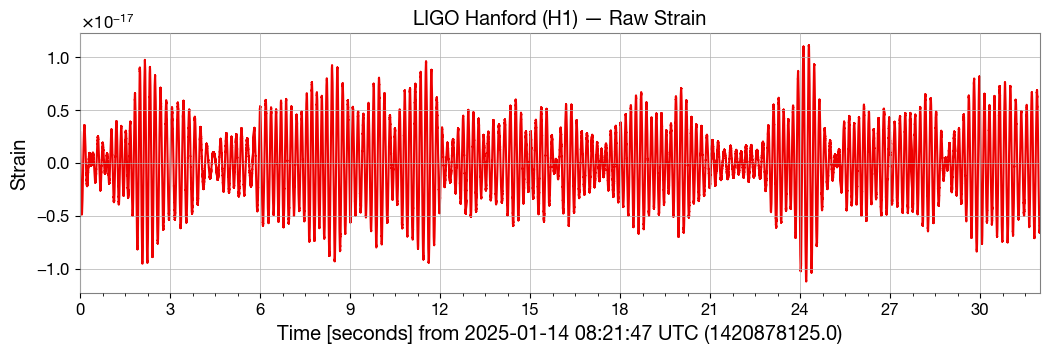

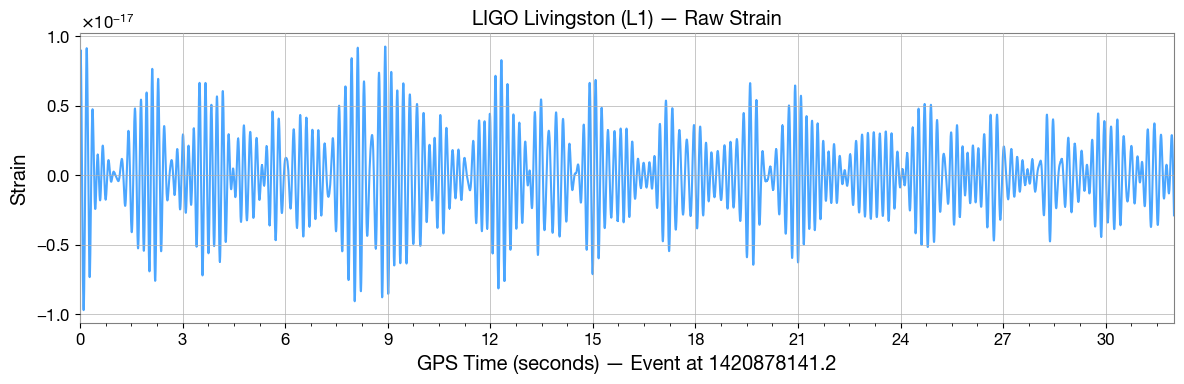

In [14]:
# Plot the raw strain data for both detectors

# H1 (Hanford)
plot_h = hdata.plot( color='gwpy:ligo-hanford')
plot_h.axes[0].set_title('LIGO Hanford (H1) — Raw Strain')
plot_h.axes[0].set_ylabel('Strain')

# L1 (Livingston)
plot_l = ldata.plot( color='gwpy:ligo-livingston')
plot_l.axes[0].set_title('LIGO Livingston (L1) — Raw Strain')
plot_l.axes[0].set_xlabel(f'GPS Time (seconds) — Event at {gps}')
plot_l.axes[0].set_ylabel('Strain')

plt.tight_layout()


As expected, the raw data looks like noise — the GW signal is completely buried. The data oscillates wildly because the dominant noise power lives at low frequencies (seismic noise below ~30 Hz) and high frequencies (shot noise above a few kHz). To reveal the signal, we need to:

1. **Characterise the noise** → estimate the Power Spectral Density (PSD)
2. **Whiten the data** → rescale by the PSD to flatten the noise spectrum
3. **Band-pass the data** → keep only the frequency range where the signal lives</VSCode.Cell>


## 4. The Power Spectral Density (PSD)

### What is the PSD?

The noise in a GW detector is a **stochastic process** $n(t)$. For stationary noise (noise whose statistical properties don't change over time), the **Power Spectral Density** $S_n(f)$ captures how the noise power is distributed across frequencies:

$$S_{n}(f) = \lim_{T \rightarrow +\infty} \frac{2}{T} \left\langle \left| \tilde{n}_{T}(f) \right|^{2} \right\rangle$$

where $\tilde{n}_T(f)$ is the Fourier transform of a noise segment of length $T$, and $\langle \cdot \rangle$ denotes an ensemble average.

A crucial property of stationary Gaussian noise: **different frequency bins are statistically independent**, with variance:

$$\langle \tilde{n}(f) \tilde{n}^*(f') \rangle = \frac{1}{2} S_n(f) \, \delta(f - f')$$

The square root of the PSD is called the **Amplitude Spectral Density (ASD)** and has units of $\text{strain} / \sqrt{\text{Hz}}$. The ASD is the standard way to visualise detector sensitivity.

### Estimating the PSD with Welch's method

Since we only have one realisation of the noise (not an ensemble), we estimate the PSD using **[Welch's method](https://en.wikipedia.org/wiki/Welch%27s_method)**:

1. Split the data into overlapping segments
2. Apply a window function to each segment (to reduce spectral leakage)
3. Compute the FFT of each segment
4. Average the squared magnitudes of all segments

There is a **trade-off**: longer segments give better frequency resolution ($\Delta f = 1/T_{\text{seg}}$), but fewer segments means more statistical fluctuations in the estimate.</VSCode.Cell>


In [15]:
# Compute PSD using Welch's method with scipy
# nperseg controls segment length: 4096 samples → frequency resolution ≈ fs/4096
fs = fs_h  # Use H1 sampling rate (should be same for both detectors)

freqs_h, psd_h = scipy.signal.welch(hdata.value, fs, window='hann', nperseg=4096)
freqs_l, psd_l = scipy.signal.welch(ldata.value, fs, window='hann', nperseg=4096)

print(f"PSD frequency bins: {len(freqs_h)}")
print(f"Frequency resolution: {freqs_h[1] - freqs_h[0]:.3f} Hz")


PSD frequency bins: 2049
Frequency resolution: 1.000 Hz


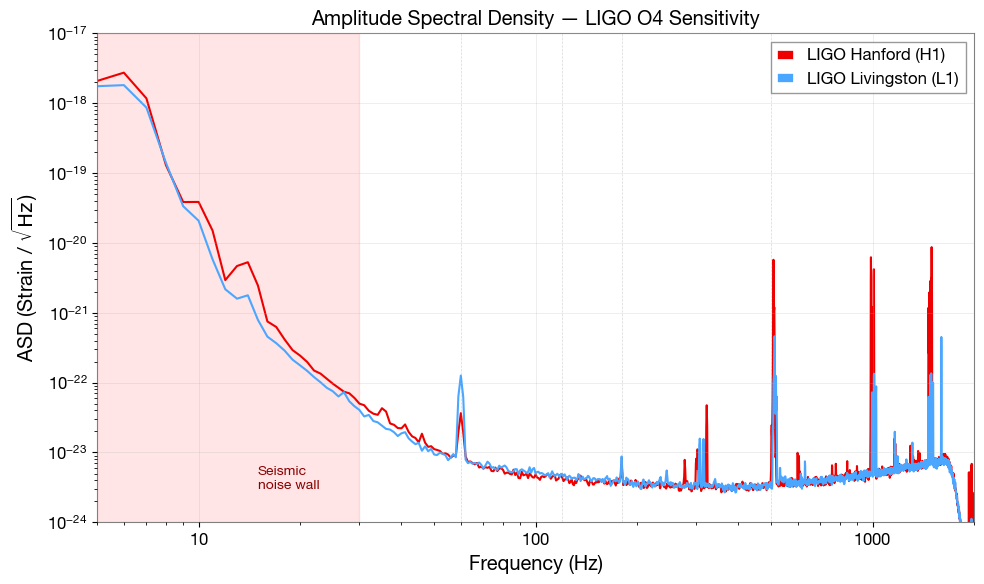

In [18]:
# Plot the Amplitude Spectral Density (ASD = sqrt(PSD)) for both detectors
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Skip the zero-frequency bin (freqs[0] = 0)
ax.loglog(freqs_h[1:], np.sqrt(psd_h[1:]), label='LIGO Hanford (H1)', color='gwpy:ligo-hanford')
ax.loglog(freqs_l[1:], np.sqrt(psd_l[1:]), label='LIGO Livingston (L1)', color='gwpy:ligo-livingston')

ax.set_xlim(5, 2000)
ax.set_ylim(1e-24, 1e-17)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel(r'ASD (Strain / $\sqrt{\mathrm{Hz}}$)')
ax.set_title('Amplitude Spectral Density — LIGO O4 Sensitivity')
ax.legend()
ax.grid(True, alpha=0.3)

# Annotate interesting features
ax.axvspan(5, 30, alpha=0.1, color='red')
ax.annotate('Seismic\nnoise wall', xy=(15, 3e-24), fontsize=10, color='darkred')

# Highlight spectral lines
for fline in [60, 120, 180, 500]:
    ax.axvline(fline, color='gray', alpha=0.3, linestyle='--', linewidth=0.5)

plt.tight_layout()


### Interpreting the ASD

The ASD plot reveals the characteristic sensitivity curve of the LIGO detectors in O4:

- **Below ~20–30 Hz**: Seismic noise dominates — the ground shakes too much
- **~30–200 Hz**: The most sensitive band — where most GW signals are detected
- **~200–1000 Hz**: Thermal noise from the mirror suspensions and coatings
- **Above ~1000 Hz**: Shot noise from photon counting statistics dominates

The sharp vertical lines (e.g. at 60, 120, 180 Hz) are **spectral lines** — narrow-band noise from the electric power grid (60 Hz in the US) and its harmonics, plus calibration lines deliberately injected to track the detector response.

> **Note**: The two LIGO detectors (H1 and L1) have nearly identical design, but their noise curves differ slightly due to different local environments (Hanford, WA vs. Livingston, LA).</VSCode.Cell>


## 5. Whitening and Band-passing the Data

### Why whiten?

The raw strain data is **colored noise**: different frequencies have vastly different power (as we just saw in the ASD plot). This makes it impossible to see a GW signal by eye.

**Whitening** rescales the data in the frequency domain so that all frequency bins have the same variance:

$$\tilde{d}_j^{\rm w} \equiv \sqrt{\frac{2 \Delta f}{S_n(f_j)}} \, \tilde{d}_j$$

After whitening, the noise becomes **white** — every frequency bin contributes equally. The Fourier bins of white noise are independent Gaussian variables with $\sigma = 1$. In the code below we implement the same idea using NumPy's discrete `rfft/irfft` convention, where the corresponding whitening factor is `ASD / \sqrt{2\,dt}`.

### Why band-pass?

Even after whitening, data at very low frequencies (dominated by seismic noise) and very high frequencies (dominated by shot noise, and where the signal has negligible power) adds no useful information about the GW signal. We apply a **band-pass filter** to keep only the frequency range where the signal lives:

$$\tilde{d}_j^{\rm wbp}(f) \equiv \tilde{w}_{\rm bp}(f) \, \tilde{d}_j^{\rm w}(f)$$

where $\tilde{w}_{\rm bp}(f)$ smoothly tapers to zero at the band edges.

In [19]:
# Helper function: smooth band-pass window (Tukey-like tapering)
def bandpass_window(freqs, f_low, f_high, taper_width_low=5., taper_width_high=50.):
    """
    Create a band-pass window that smoothly tapers to zero at the edges.
    
    Parameters:
    - freqs: array of frequencies
    - f_low, f_high: passband limits (Hz)
    - taper_width_low, taper_width_high: width of the cosine taper at each edge (Hz)
    
    Returns:
    - window: array of same shape as freqs, values in [0, 1]
    """
    window = np.ones_like(freqs)
    
    # Taper at low frequencies: 0 at f_low, 1 at f_low + taper_width_low
    mask_low = (freqs > f_low) & (freqs < f_low + taper_width_low)
    window[mask_low] = 0.5 * (1 - np.cos(np.pi * (freqs[mask_low] - f_low) / taper_width_low))
    
    # Set to zero below f_low
    window[freqs <= f_low] = 0.0
    
    # Taper at high frequencies: 1 at f_high - taper_width_high, 0 at f_high
    mask_high = (freqs > f_high - taper_width_high) & (freqs < f_high)
    window[mask_high] = 0.5 * (1 + np.cos(np.pi * (freqs[mask_high] - (f_high - taper_width_high)) / taper_width_high))
    
    # Set to zero above f_high
    window[freqs >= f_high] = 0.0
    
    return window


def whiten_bandpass(data_timeseries, asd_func, f_low=20, f_high=400, 
                    taper_low=10., taper_high=100.):
    """
    Whiten and band-pass a GWpy TimeSeries.
    
    Parameters:
    - data_timeseries: GWpy TimeSeries object
    - asd_func: interpolation function for the ASD (Hz → ASD value)
    - f_low, f_high: band-pass limits (Hz)
    - taper_low, taper_high: taper widths (Hz)
    
    Returns:
    - times: time array (seconds from start)
    - whitened_td: whitened, band-passed time-domain data
    - window_bp: the band-pass window used
    - freqs_fd: the positive-frequency grid used in the FFT
    """
    N = len(data_timeseries)
    dt = data_timeseries.dt.value
    
    # Apply a time-domain Tukey window to limit edge transients before the FFT
    tukey_win = scipy.signal.windows.tukey(N, alpha=0.1)
    data_windowed = tukey_win * data_timeseries.value
    
    # Use the standard NumPy FFT convention for time-domain whitening.
    # With this convention, dividing by ASD / sqrt(2*dt) gives a whitened
    # time series whose unfiltered samples have RMS close to 1 for stationary noise.
    data_fd = np.fft.rfft(data_windowed)
    freqs_fd = np.fft.rfftfreq(N, d=dt)
    whiten_norm = asd_func(freqs_fd) / np.sqrt(2 * dt)
    
    # Build the band-pass window and suppress frequencies outside the signal band.
    window_bp = bandpass_window(freqs_fd, f_low, f_high, taper_low, taper_high)
    data_wbp = window_bp * data_fd / whiten_norm
    
    # Transform back to the time domain using the matching inverse FFT convention.
    data_wbp_td = np.fft.irfft(data_wbp, n=N)
    times = dt * np.arange(len(data_wbp_td))
    
    return times, data_wbp_td, window_bp, freqs_fd

In [20]:
# Compute ASDs using GWpy's built-in method (for the interpolation functions)
asd_h = hdata.asd(fftlength=2., method="median")
asd_l = ldata.asd(fftlength=2., method="median")

# Create interpolation functions for the ASDs
from scipy.interpolate import interp1d
asd_h_interp = interp1d(asd_h.frequencies.value, asd_h.value, 
                         bounds_error=False, fill_value=np.inf)
asd_l_interp = interp1d(asd_l.frequencies.value, asd_l.value,
                         bounds_error=False, fill_value=np.inf)

# Whiten and band-pass both detectors
# For a compact binary merger, the interesting frequencies are ~20–500 Hz
print("Whitening H1 data...")
times_h, h_wbp, window_h, freqs_fd_h = whiten_bandpass(
    hdata, asd_h_interp, f_low=20, f_high=500, taper_low=10., taper_high=100.
)

print("Whitening L1 data...")
times_l, l_wbp, window_l, freqs_fd_l = whiten_bandpass(
    ldata, asd_l_interp, f_low=20, f_high=500, taper_low=10., taper_high=100.
)

# For white noise, band-passing reduces the time-domain RMS by roughly sqrt(mean(window^2)).
expected_rms_h = np.sqrt(np.mean(window_h**2))
expected_rms_l = np.sqrt(np.mean(window_l**2))

print("✓ Whitening complete!")
print(f"  H1 whitened data shape: {h_wbp.shape}")
print(f"  L1 whitened data shape: {l_wbp.shape}")
print(f"  H1 filtered RMS: {np.std(h_wbp):.3f}  (expected ≈ {expected_rms_h:.3f})")
print(f"  L1 filtered RMS: {np.std(l_wbp):.3f}  (expected ≈ {expected_rms_l:.3f})")
print("  RMS < 1 is expected here: whitening makes the full-band noise unit scale, and band-passing removes part of that variance.")


Whitening H1 data...
Whitening L1 data...
✓ Whitening complete!
  H1 whitened data shape: (131072,)
  L1 whitened data shape: (131072,)
  H1 filtered RMS: 0.450  (expected ≈ 0.448)
  L1 filtered RMS: 0.454  (expected ≈ 0.448)
  RMS < 1 is expected here: whitening makes the full-band noise unit scale, and band-passing removes part of that variance.


### Sanity check: the ASD and FFT normalization

Before looking at the time domain, let's verify that our ASD estimate is consistent with the Fourier-domain data. For the convention `dt × rfft(data)`, stationary noise should satisfy

$$|\tilde{d}(f)| \sim \frac{\mathrm{ASD}(f)}{\sqrt{2\,\Delta f}}$$

up to random scatter from one frequency bin to the next. This is a **frequency-domain PSD check**. The time-domain whitening used below adopts a different normalization, chosen so that the unfiltered whitened samples have RMS close to 1 for stationary noise; after the 20–500 Hz band-pass, the RMS becomes smaller because only part of the full band is retained.

### How to interpret the filtered RMS

At this stage there are **two different but compatible sanity checks**:

1. In the **frequency domain**, the PSD-normalized spectrum should sit at order unity across the passband.
2. In the **time domain**, the *unfiltered* whitened noise would have RMS close to 1.
3. After the **20–500 Hz band-pass**, the RMS drops below 1 because we deliberately discard part of the noise power along with irrelevant frequencies.

For this notebook, the filtered RMS should be roughly set by $\sqrt{\langle w_{\rm bp}^2 \rangle}$, where $w_{\rm bp}(f)$ is the band-pass window. That gives a useful rule of thumb for deciding whether the whitening and filtering behave as expected.

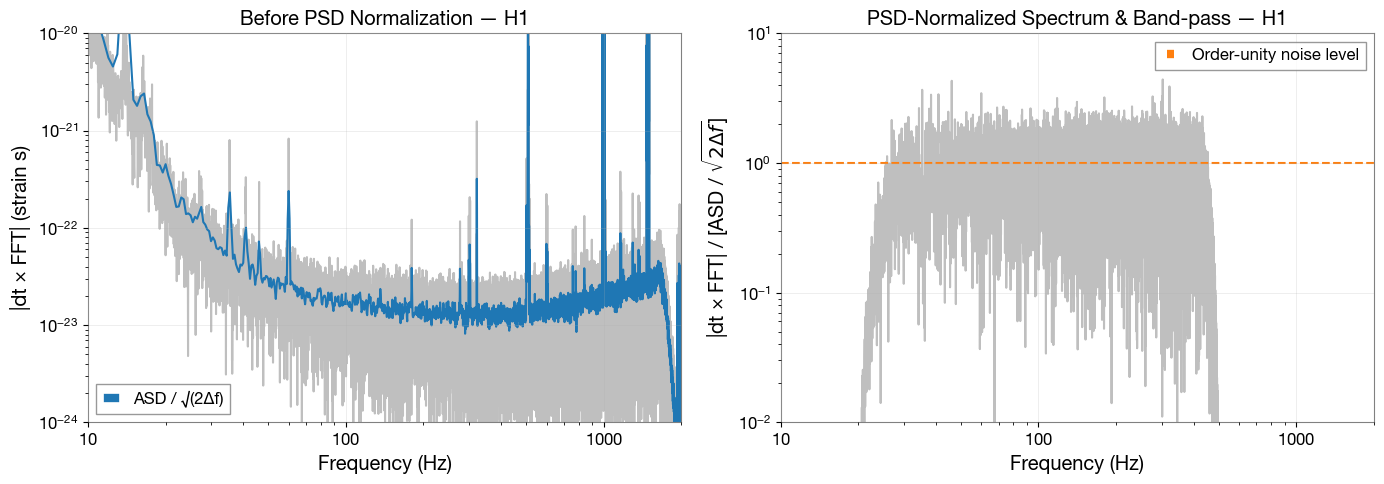

In [21]:
# Reconstruct the frequency-domain amplitudes for a PSD normalization check
N_h = len(hdata)
dt_h_val = hdata.dt.value
df_h = 1.0 / (N_h * dt_h_val)

# Use dt * rfft here because the one-sided PSD convention is
# S_n(f) ≈ (2 / T) |dt * rfft(data)|^2
tukey_h = scipy.signal.windows.tukey(N_h, alpha=0.1)
h_fd = np.fft.rfft(tukey_h * hdata.value) * dt_h_val
freqs_fd_h = np.fft.rfftfreq(N_h, d=dt_h_val)
h_fd_psdnorm = window_h * h_fd / (asd_h_interp(freqs_fd_h) / np.sqrt(2 * df_h))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before PSD normalization
axes[0].loglog(freqs_fd_h[1:], np.abs(h_fd[1:]), alpha=0.5, color='gray')
axes[0].loglog(asd_h.frequencies.value[1:], asd_h.value[1:] / np.sqrt(2 * df_h), 
               'C0', label='ASD / √(2Δf)')
axes[0].set_xlim(10, 2000)
axes[0].set_ylim(1e-24, 1e-20)
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('|dt × FFT| (strain s)')
axes[0].set_title('Before PSD Normalization — H1')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# After PSD normalization and band-limiting
axes[1].loglog(freqs_fd_h[1:], np.abs(h_fd_psdnorm[1:]), alpha=0.5, color='gray')
axes[1].axhline(1.0, color='C1', linestyle='--', label='Order-unity noise level')
axes[1].set_xlim(10, 2000)
axes[1].set_ylim(1e-2, 10)
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel(r'|dt × FFT| / [ASD / $\sqrt{2\Delta f}$]')
axes[1].set_title('PSD-Normalized Spectrum & Band-pass — H1')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

## 6. Revealing the Gravitational-Wave Signal

Now for the exciting part! The whitened, band-passed time-domain data should show the GW signal clearly above the noise.

Remember: in whitened data, the noise is **white** before band-limiting. After we additionally restrict the data to 20–500 Hz, the residual time-domain noise has an RMS below 1 because we have removed most of the available frequency band. Any coherent structure that emerges on top of that filtered noise is a real feature of the data. A GW signal will appear as a **coherent oscillation that grows in amplitude and frequency**, peaking at the merger time, then ringing down.

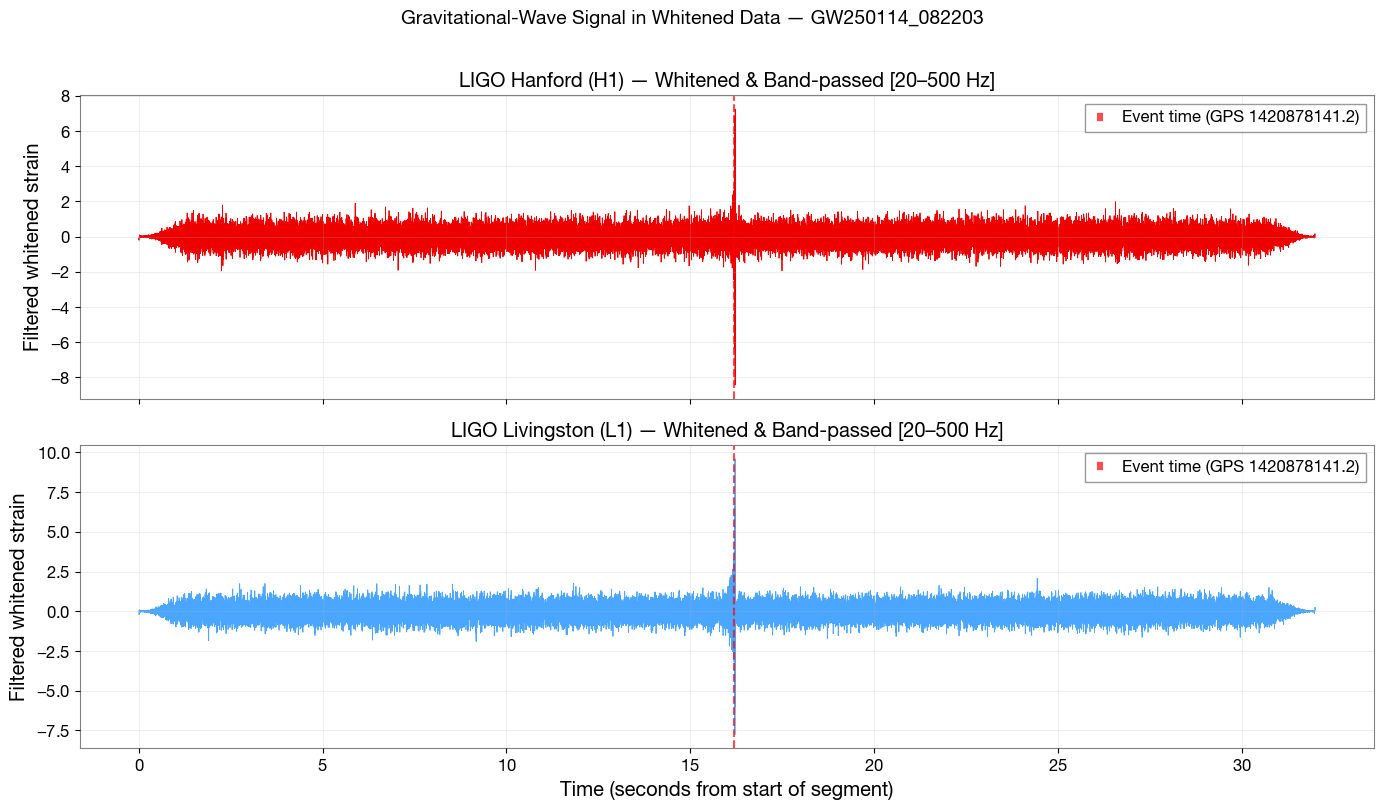

In [22]:
# Plot the whitened, band-passed time-domain data for BOTH detectors
# The event GPS time is at event_time_in_segment seconds from the start

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# H1
axes[0].plot(times_h, h_wbp, color='gwpy:ligo-hanford', linewidth=0.6)
axes[0].axvline(x=event_time_in_segment, color='red', linestyle='--', alpha=0.7, label=f'Event time (GPS {gps})')
axes[0].set_ylabel('Filtered whitened strain')
axes[0].set_title('LIGO Hanford (H1) — Whitened & Band-passed [20–500 Hz]')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# L1
axes[1].plot(times_l, l_wbp, color='gwpy:ligo-livingston', linewidth=0.6)
axes[1].axvline(x=event_time_in_segment, color='red', linestyle='--', alpha=0.7, label=f'Event time (GPS {gps})')
axes[1].set_xlabel('Time (seconds from start of segment)')
axes[1].set_ylabel('Filtered whitened strain')
axes[1].set_title('LIGO Livingston (L1) — Whitened & Band-passed [20–500 Hz]')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Gravitational-Wave Signal in Whitened Data — GW250114_082203', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()


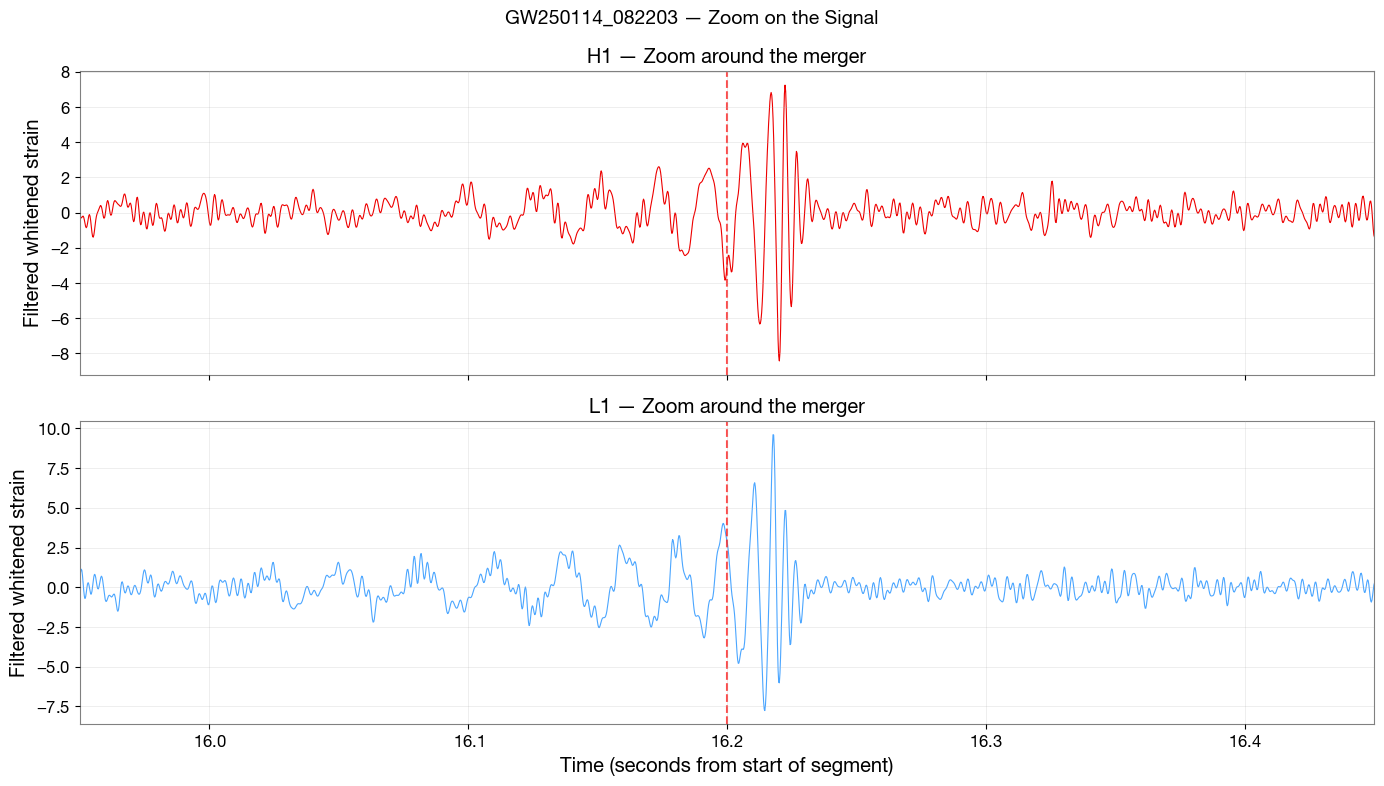

In [23]:
# Zoom in around the event time (±1 second)
zoom_halfwidth = 0.25
zoom_start = event_time_in_segment - zoom_halfwidth
zoom_end = event_time_in_segment + zoom_halfwidth

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(times_h, h_wbp, color='gwpy:ligo-hanford', linewidth=0.8)
axes[0].axvline(x=event_time_in_segment, color='red', linestyle='--', alpha=0.7)
axes[0].set_xlim(zoom_start, zoom_end)
axes[0].set_ylabel('Filtered whitened strain')
axes[0].set_title('H1 — Zoom around the merger')
axes[0].grid(True, alpha=0.3)

axes[1].plot(times_l, l_wbp, color='gwpy:ligo-livingston', linewidth=0.8)
axes[1].axvline(x=event_time_in_segment, color='red', linestyle='--', alpha=0.7)
axes[1].set_xlim(zoom_start, zoom_end)
axes[1].set_xlabel('Time (seconds from start of segment)')
axes[1].set_ylabel('Filtered whitened strain')
axes[1].set_title('L1 — Zoom around the merger')
axes[1].grid(True, alpha=0.3)

plt.suptitle('GW250114_082203 — Zoom on the Signal', fontsize=14, fontweight='bold')
plt.tight_layout()


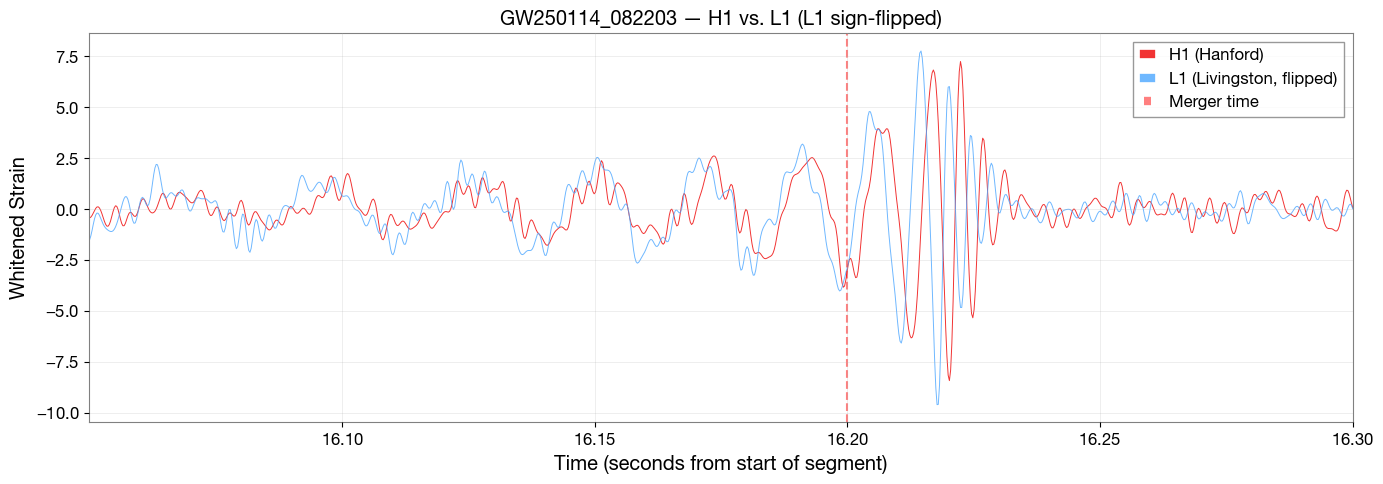

In [24]:
# Overlay both detectors for a direct comparison
fig, ax = plt.subplots(1, 1, figsize=(14, 5))

ax.plot(times_h, h_wbp, color='gwpy:ligo-hanford', linewidth=0.7, alpha=0.8, label='H1 (Hanford)')
ax.plot(times_l, -l_wbp, color='gwpy:ligo-livingston', linewidth=0.7, alpha=0.8, label='L1 (Livingston, flipped)')
ax.axvline(x=event_time_in_segment, color='red', linestyle='--', alpha=0.5, label=f'Merger time')

ax.set_xlim(event_time_in_segment - 0.15, event_time_in_segment + 0.1)
ax.set_xlabel('Time (seconds from start of segment)')
ax.set_ylabel('Whitened Strain')
ax.set_title('GW250114_082203 — H1 vs. L1 (L1 sign-flipped)', fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()


### What do we see?

The whitened, band-passed data reveals a clear **chirp-like signal** — the hallmark of a compact binary coalescence:

1. **Inspiral**: The signal starts at low amplitude and high frequency, slowly growing. The binary's orbit shrinks due to gravitational-wave emission.

2. **Merger**: A sharp peak in amplitude as the two objects plunge together.

3. **Ringdown**: A rapid decay as the merged remnant settles into a stable state.

We can see the signal in **both detectors** (H1 and L1). In the overlay plot, we flipped the sign of L1 — this is because the detectors have different orientations, and a GW signal can appear with opposite sign in different detectors (or even be absent in one, if the source is in a blind spot). The fact that we see a **coherent, consistent signal in both detectors** is a strong indicator that this is a real astrophysical event, not a detector glitch!

### Why does whitening work?

Without whitening, the data is coloured noise — low frequencies dominate the raw strain by orders of magnitude. The GW signal lives in a narrow band and is completely drowned out. After dividing by the ASD, every frequency contributes equally, and the signal — which is a coherent pattern across frequency — stands out above the now-uniform white noise background.</VSCode.Cell>


## 7. Spectrograms: a short and clear view of the chirp

For a quick pedagogical view, we will make spectrograms from the **already whitened and band-passed** data from Section 5. This suppresses low-frequency seismic noise and makes the chirp easier to isolate.

Minimal recipe:
1. Use short FFTs (`fftlength = 0.064 s`) and high overlap for better time tracking.
2. Zoom tightly around merger (`+-0.20 s`) and focus on the most informative band (`30-350 Hz`).
3. Plot **excess power**: divide each frequency bin by its median over time. This removes broad stationary background and highlights the transient chirp.
4. Use logarithmic color scaling (`LogNorm`) on this excess-power map.

This keeps the section short while making the signal track much easier to see in both detectors.

If the track is still faint: set twin=0.15 or lower fmax to 250 Hz.


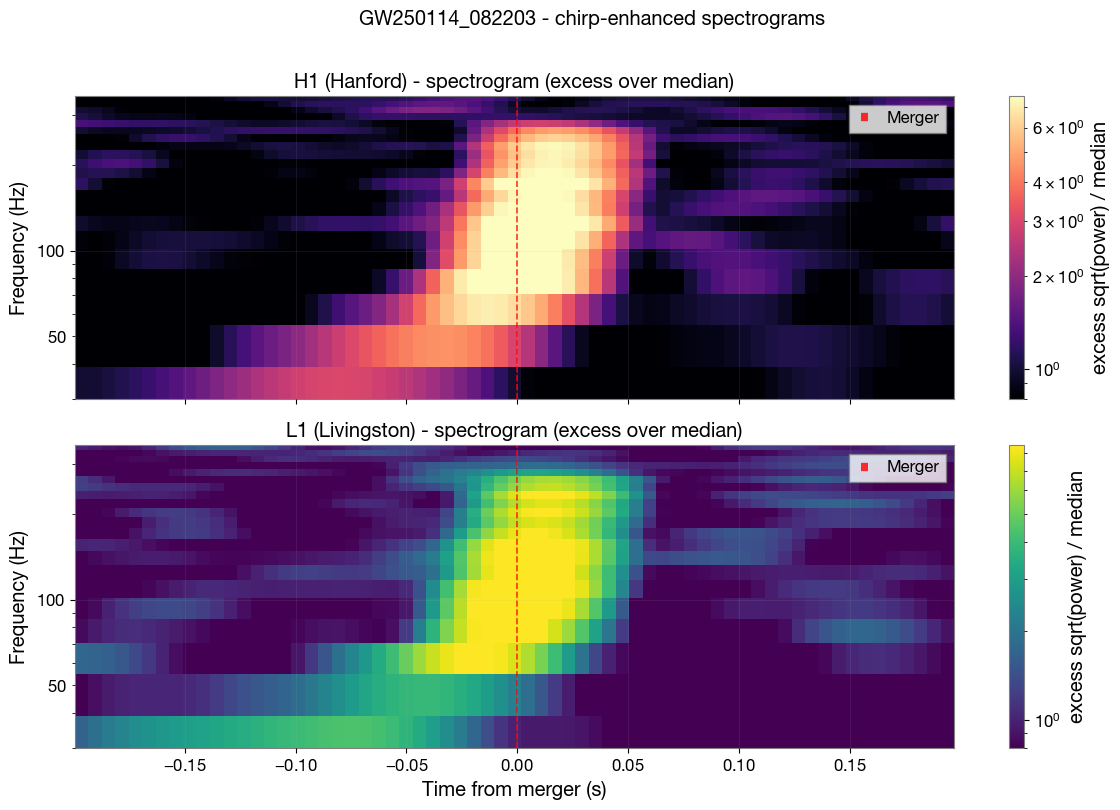

In [25]:
# Compact, pedagogical spectrogram view focused on signal visibility
from matplotlib.colors import LogNorm
from gwpy.timeseries import TimeSeries

# Reuse filtered-whitened data from Section 5 to enhance transient visibility
h_wbp_ts = TimeSeries(h_wbp, dt=hdata.dt.value, t0=hdata.t0.value)
l_wbp_ts = TimeSeries(l_wbp, dt=ldata.dt.value, t0=ldata.t0.value)

fftlength = 0.064   # s -> better time localization for short BBH chirp
overlap = 0.058      # s -> smooth time evolution
fmin, fmax = 30, 350
twin = 0.20          # seconds around merger

def make_zoomed_spec(ts):
    spec = ts.spectrogram2(fftlength=fftlength, overlap=overlap, window='hann') ** 0.5
    times_rel = spec.times.value - gps
    tmask = (times_rel >= -twin) & (times_rel <= twin)
    z = spec.value[tmask, :]

    # Pedagogical trick: normalize each frequency bin by its time-median
    # to suppress stationary background and highlight transient excess power.
    floor = np.percentile(z[z > 0], 1) if np.any(z > 0) else 1e-12
    bg = np.median(z, axis=0, keepdims=True)
    z_excess = z / np.maximum(bg, floor)

    positive = z_excess[z_excess > 0]
    vmin = 0.8
    vmax = np.percentile(positive, 99.5) if positive.size else 5.0
    if vmax <= vmin:
        vmax = vmin * 5.0

    return spec, times_rel[tmask], z_excess, vmin, vmax

spec_h, t_h, z_h, vmin_h, vmax_h = make_zoomed_spec(h_wbp_ts)
spec_l, t_l, z_l, vmin_l, vmax_l = make_zoomed_spec(l_wbp_ts)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for ax, spec, tt, zz, vmin, vmax, title, cmap in [
    (axes[0], spec_h, t_h, z_h, vmin_h, vmax_h, 'H1 (Hanford)', 'magma'),
    (axes[1], spec_l, t_l, z_l, vmin_l, vmax_l, 'L1 (Livingston)', 'viridis'),
]:
    pcm = ax.pcolormesh(
        tt,
        spec.frequencies.value,
        zz.T,
        shading='auto',
        cmap=cmap,
        norm=LogNorm(vmin=vmin, vmax=vmax),
    )
    ax.axvline(0, color='red', linestyle='--', linewidth=1.2, alpha=0.8, label='Merger')
    ax.set_yscale('log')
    ax.set_ylim(fmin, fmax)
    ax.set_ylabel('Frequency (Hz)')
    ax.set_title(f'{title} - spectrogram (excess over median)')
    ax.grid(True, alpha=0.15)
    ax.legend(loc='upper right')
    cbar = fig.colorbar(pcm, ax=ax)
    cbar.set_label('excess sqrt(power) / median')

axes[1].set_xlabel('Time from merger (s)')
plt.suptitle('GW250114_082203 - chirp-enhanced spectrograms', fontweight='bold', y=1.01)
plt.tight_layout()

print('If the track is still faint: set twin=0.15 or lower fmax to 250 Hz.')

## 8. Summary

In this hands-on tutorial, we have:

| Step | What we did | Key takeaway |
|---|---|---|
| **1. Data access** | Downloaded 32 s of real LIGO strain for GW250114_082203 using GWpy | GWOSC provides free, open access to GW data |
| **2. Raw inspection** | Plotted the time-domain strain | Raw data is dominated by coloured noise; signals are invisible |
| **3. PSD estimation** | Computed the ASD using Welch's method | The PSD captures how noise power is distributed across frequencies |
| **4. Whitening** | Divided the FFT by the ASD | Whitening flattens the noise spectrum so all frequencies have equal weight |
| **5. Band-passing** | Kept only 20–500 Hz with smooth tapers | Removing irrelevant frequencies reduces background fluctuations |
| **6. Signal reveal** | Plotted the whitened time-domain data | **The GW chirp signal is clearly visible in both H1 and L1!** |
| **7. Spectrogram** | Computed time-frequency spectrograms of both detectors | **The chirp track is visible as a sweeping curve in the time-frequency plane!** |

---

### Where to go next

- **`template_mf_tutorial.ipynb`** ← the natural continuation of this notebook:
  - Generating IMR waveform templates (TD and FD, different approximants)
  - Matched filtering and the noise-weighted inner product
  - Intuitive visualisation of how SNR depends on time alignment
  - A short parameter-estimation run with bilby

- **`gwtc5_tutorial.ipynb`**: Explore the full GWTC-5.0 catalog — population plots, error bars, corner plots and prior-vs-posterior comparisons

- **Matched filtering deep-dive** (Tutorials 4.1–4.2 from the ODW): use PyCBC's template banks and significance estimation

---

*This notebook uses data from the Gravitational Wave Open Science Center (GWOSC), a service of LIGO Laboratory, the LIGO Scientific Collaboration, the Virgo Collaboration, and KAGRA.*
